In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.features.feature_engineer.min_features import min_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s22 = pd.read_csv('data/raw/season_stats/S22.csv').sort_values(by='GAME_DATE')
p22 = pd.read_csv('data/raw/playoff_stats/P22.csv').sort_values(by='GAME_DATE')
s22 = pd.concat([s22, p22])

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
p23 = pd.read_csv('data/raw/playoff_stats/P23.csv').sort_values(by='GAME_DATE')
s23 = pd.concat([s23, p23])

s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
p24 = pd.read_csv('data/raw/playoff_stats/P24.csv').sort_values(by='GAME_DATE')
s24 = pd.concat([s24, p24])

s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
p25 = pd.read_csv('data/raw/playoff_stats/P25.csv').sort_values(by='GAME_DATE')
s25 = pd.concat([s25, p25])

s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
p26 = pd.read_csv('data/raw/playoff_stats/P26.csv').sort_values(by='GAME_DATE')
s26 = pd.concat([s26, p26])

In [3]:
print(f"Length of orginal dataset: {len(s22)}")
s22 = s22.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(s22)}")

print(f"Length of orginal dataset: {len(s23)}")
s23 = s23.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(s23)}")

print(f"Length of orginal dataset: {len(s24)}")
s24 = s24.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(s24)}")

print(f"Length of orginal dataset: {len(s25)}")
s25 = s25.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(s25)}")

print(f"Length of orginal dataset: {len(s26)}")
s26 = s26.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(s26)}")


print(f"Length of orginal dataset: {len(p22)}")
p22 = p22.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(p22)}")

print(f"Length of orginal dataset: {len(p23)}")
p23 = p23.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(p23)}")

print(f"Length of orginal dataset: {len(p24)}")
p24 = p24.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(p24)}")

print(f"Length of orginal dataset: {len(p25)}")
p25 = p25.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(p25)}")

print(f"Length of orginal dataset: {len(p26)}")
p26 = p26.drop_duplicates(subset=['PLAYER_ID', 'GAME_ID'])
print(f"After dropping duplicates: {len(p26)}")

s22 = pd.concat([s22, p22])
s23 = pd.concat([s23, p23])
s24 = pd.concat([s24, p24])
s25 = pd.concat([s25, p25])
s26 = pd.concat([s26, p26])


Length of orginal dataset: 29821
After dropping duplicates: 27930
Length of orginal dataset: 29350
After dropping duplicates: 27622
Length of orginal dataset: 28086
After dropping duplicates: 28086
Length of orginal dataset: 28110
After dropping duplicates: 28110
Length of orginal dataset: 27764
After dropping duplicates: 27764
Length of orginal dataset: 1891
After dropping duplicates: 1891
Length of orginal dataset: 1728
After dropping duplicates: 1728
Length of orginal dataset: 1685
After dropping duplicates: 1685
Length of orginal dataset: 1804
After dropping duplicates: 1804
Length of orginal dataset: 1113
After dropping duplicates: 1113


In [32]:
res = []
for df in [s22, s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)
    df['STARTING'] = df['START_POSITION'].notna().astype(int)

    df = min_features(df)
    df['STARTING_X_SPREAD_ABS'] = df['STARTING'] * df['TEAM_SPREAD'].abs()
    df['TOP_STAR_ACTIVE_X_STARTING'] = df['TOP_STAR_ACTIVE'] * df['STARTING']
    df['ACTIVE_STARS_COUNT_X_STARTING'] = df['ACTIVE_STARS_COUNT'] * df['STARTING']


    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))

    # Calculate the player's personal season-to-date baseline
    player_stats = df.groupby('PLAYER_ID')['MIN']
    # Use expanding() to avoid look-ahead bias (only uses games played UP TO that date)
    df['MIN_SEASON_MEAN'] = player_stats.transform(lambda x: x.expanding().mean().shift(1))
    df['MIN_SEASON_STD'] = player_stats.transform(lambda x: x.expanding().std().shift(1))
    # The Z-score of their current 10-game average relative to their own season
    df['MIN_ROLE_Z_SCORE'] = (df['MIN_roll10'] - df['MIN_SEASON_MEAN']) / df['MIN_SEASON_STD']
    df['MIN_VOLATILITY_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(
    lambda x: x.rolling(window=10, min_periods=1).std().shift(1))
    df['MIN_VOLATILITY_RELATIVE'] = df['MIN_VOLATILITY_L10'] / df['MIN_roll10']
    df['MIN_TREND'] = df['MIN_5_ewm'] - df['MIN_SEASON_MEAN']
        
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    df['ROLE_LOCK'] = (
        df['STARTER_ROLL10_PCT'] *                         
        np.exp(-df['MIN_std10'] / df['MIN_10_ewm']))
    df['ROLE_SHOCK'] = (df['MIN_5_ewm'] - df['MIN_SEASON_MEAN']) / df['MIN_SEASON_MEAN']                            

    df['MIN_MIN_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).min())
    df['MIN_MAX_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).max())
    # Does this player's rank on the team make them a "Garbage Time" candidate?

    df['MIN_deviation'] = df['MIN_lag1'] - df['MIN_roll10']

    df = df[(df['MIN'] > 0) & (df['MIN'] <= 48)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.sample(10)

(147632, 350)


,Unnamed: 0.2,Unnamed: 0.1,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,IS_PLAYOFF,POS,AGE,TEAM_SPREAD_ODDS,GAME_TOTAL_ODDS,TEAM_SPREAD,GAME_TOTAL,STARTING,PTS_PER_MIN,AST_PER_MIN,REB_PER_MIN,IS_HOME,POSITION_ENCODED,MIN_roll5,PTS_roll5,PLUS_MINUS_roll5,PF_roll5,POSS_roll5,PIE_roll5,USG_PCT_roll5,TS_PCT_roll5,NET_RATING_roll5,MIN_roll10,PTS_roll10,PLUS_MINUS_roll10,PF_roll10,POSS_roll10,PIE_roll10,USG_PCT_roll10,TS_PCT_roll10,NET_RATING_roll10,MIN_roll20,PTS_roll20,PLUS_MINUS_roll20,PF_roll20,POSS_roll20,PIE_roll20,USG_PCT_roll20,TS_PCT_roll20,NET_RATING_roll20,MIN_5_ewm,PTS_5_ewm,PLUS_MINUS_5_ewm,PF_5_ewm,POSS_5_ewm,PIE_5_ewm,USG_PCT_5_ewm,TS_PCT_5_ewm,NET_RATING_5_ewm,DIST_5_ewm,SPD_5_ewm,TCHS_5_ewm,MIN_10_ewm,PTS_10_ewm,PLUS_MINUS_10_ewm,PF_10_ewm,POSS_10_ewm,PIE_10_ewm,USG_PCT_10_ewm,TS_PCT_10_ewm,NET_RATING_10_ewm,DIST_10_ewm,SPD_10_ewm,TCHS_10_ewm,MIN_20_ewm,PTS_20_ewm,PLUS_MINUS_20_ewm,PF_20_ewm,POSS_20_ewm,PIE_20_ewm,USG_PCT_20_ewm,TS_PCT_20_ewm,NET_RATING_20_ewm,DIST_20_ewm,SPD_20_ewm,TCHS_20_ewm,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,STARTER_ROLL10_PCT,MIN_ewm_season_avg,PTS_ewm_season_avg,PLUS_MINUS_ewm_season_avg,PF_ewm_season_avg,POSS_ewm_season_avg,PIE_ewm_season_avg,USG_PCT_ewm_season_avg,TS_PCT_ewm_season_avg,NET_RATING_ewm_season_avg,STAR_PLAYER_ID,STAR_OUT_FLAG,STAR_POS,STAR_SAME_POS,STAR_SAME_POS_GROUP,MIN_WHEN_STAR_IN,MIN_WHEN_STAR_OUT,MIN_STAR_OUT_DELTA,TEAM_PACE_roll10,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,GAME_NUMBER,MIN_std10,MIN_std5,MIN_std20,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,OPP_NET_RATING_roll5,OPP_NET_RATING_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,TOP_PLAYER,SECOND_TOP_PLAYER,THIRD_TOP_PLAYER,IS_TOP_STAR,IS_TOP_1_STAR,ACTIVE_STARS_COUNT,TOP_STAR_ACTIVE,TOP_PLAYER_ACTIVE,SECOND_PLAYER_ACTIVE,THIRD_PLAYER_ACTIVE,HOME_AVG_PTS_PER_MIN_TO_DATE,AWAY_AVG_PTS_PER_MIN_TO_DATE,PLAYER_HOME_PTS_PER_MIN_DELTA,PLAYER_AWAY_PTS_PER_MIN_DELTA,HOME_AVG_USG_PCT_TO_DATE,AWAY_AVG_USG_PCT_TO_DATE,PLAYER_HOME_USG_PCT_DELTA,PLAYER_AWAY_USG_PCT_DELTA,HOME_AVG_POSS_TO_DATE,AWAY_AVG_POSS_TO_DATE,PLAYER_HOME_POSS_DELTA,PLAYER_AWAY_POSS_DELTA,

In [34]:
MIN_FEATURES = [
    'STARTING_X_SPREAD_ABS',
    'MIN_5_ewm',
    'TEAM_MIN_RANK_L10',
    'STARTER_ROLL10_PCT',
    'MIN_SEASON_MEAN',
    'MIN_lag1',
    'MIN_SEASON_STD',
    'MIN_MAX_L10',
    'IS_PLAYOFF',

    #new 
    'MIN_deviation',
    'ACTIVE_STARS_COUNT',
    'EXPECTED_PACE',
    'MIN_TREND',
]

### NaN Percentage by feature

In [35]:
from sklearn.model_selection import TimeSeriesSplit

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = (
    df[MIN_FEATURES + ["MIN", "GAME_DATE"]]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = ppm_df[MIN_FEATURES]
y = ppm_df["MIN"]

quantiles = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective          = "reg:quantileerror",
    n_estimators       = 1828,
    max_depth          = 5,
    learning_rate      = 0.019058023170429123,
    subsample          = 0.6604528698837521,
    colsample_bytree   = 0.6710615957337823,
    reg_alpha          = 0.004619045167128926,
    reg_lambda         = 0.06143534302677916,
    min_child_weight   = 3,
    n_jobs             = -1,
    random_state       = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key        = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


def score_fold(actual, preds, models, fold_label):
    lower    = preds["q_0.10"]
    median   = preds["q_0.50"]
    upper    = preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))
    metrics  = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }
    print(f"{fold_label:30s} | MAE: {metrics['mae']:.3f} | "
          f"R²: {metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%}")
    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparameter tuning)
#
# Use this to compare models or features without data leakage.
# NOT your final performance estimate — train set grows each fold
# which inflates later folds.
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────")
print(f"Training data size: {len(X)}")

tscv        = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, f"TSCV fold {fold+1}")
    tscv_results.append(metrics)

maes = [r["mae"] for r in tscv_results]
r2s  = [r["r2"]  for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


── Phase 1: TimeSeriesSplit ─────────────────────────────────────
Training data size: 147632
TSCV fold 1                    | MAE: 4.597 | R²: 0.714 | 80% Coverage: 77.1%
TSCV fold 2                    | MAE: 4.392 | R²: 0.729 | 80% Coverage: 78.3%
TSCV fold 3                    | MAE: 4.315 | R²: 0.751 | 80% Coverage: 79.1%
TSCV fold 4                    | MAE: 4.325 | R²: 0.725 | 80% Coverage: 79.6%
TSCV fold 5                    | MAE: 4.330 | R²: 0.699 | 80% Coverage: 79.7%

TimeSeriesSplit Summary
  MAE      : 4.392 ± 0.106
  R²       : 0.724  ± 0.017
  Coverage : 78.8% ± 1.0%  (target ~80%)


In [36]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# tscv = TimeSeriesSplit(n_splits=4)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=40, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

### Phase 2: Walk-Forward Validation

In [37]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (final validation / production simulation)
#
# Fixed training window that slides forward — mimics how you'll
# actually retrain in production. Use these numbers to decide
# whether to trust the model with real money.
# ════════════════════════════════════════════════════════════════════════════

TRAIN_WINDOW = int(len(ppm_df) * 0.50)   # fixed window size (games)
STEP_SIZE    = int(len(ppm_df) * 0.10)   # retrain every N games
N_FOLDS      = 4

wf_results = []

for fold in range(N_FOLDS):
    train_start = fold * STEP_SIZE
    train_end   = train_start + TRAIN_WINDOW
    val_end     = train_end   + STEP_SIZE

    if val_end > len(ppm_df):
        break

    X_tr  = X.iloc[train_start:train_end]
    X_val = X.iloc[train_end:val_end]
    y_tr  = y.iloc[train_start:train_end]
    y_val = y.iloc[train_end:val_end]

    date_start = ppm_df["GAME_DATE"].iloc[train_start]
    date_end   = ppm_df["GAME_DATE"].iloc[train_end - 1]
    date_val   = ppm_df["GAME_DATE"].iloc[val_end - 1]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    label   = f"WF fold {fold+1} ({date_end} → {date_val})"
    metrics = score_fold(y_val.values, preds, models, label)
    metrics.update({"train_start": date_start, "train_end": date_end, "val_end": date_val})
    wf_results.append(metrics)

maes = [r["mae"] for r in wf_results]
r2s  = [r["r2"]  for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]
print(f"\nWalk-Forward Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# Drift check — is the model degrading over time?
print("\nMAE over folds (should be stable, not rising):")
for r in wf_results:
    bar = "█" * int(r["mae"] * 4)
    print(f"  {r['fold']:30s} {r['mae']:.3f}  {bar}")

WF fold 1 (2024-01-28 00:00:00 → 2024-05-28 00:00:00) | MAE: 4.234 | R²: 0.767 | 80% Coverage: 78.6%
WF fold 2 (2024-05-28 00:00:00 → 2025-01-26 00:00:00) | MAE: 4.389 | R²: 0.725 | 80% Coverage: 80.3%
WF fold 3 (2025-01-26 00:00:00 → 2025-05-23 00:00:00) | MAE: 4.322 | R²: 0.728 | 80% Coverage: 78.9%
WF fold 4 (2025-05-23 00:00:00 → 2026-01-21 00:00:00) | MAE: 4.408 | R²: 0.690 | 80% Coverage: 80.1%

Walk-Forward Summary
  MAE      : 4.338 ± 0.068
  R²       : 0.727  ± 0.028
  Coverage : 79.5% ± 0.7%  (target ~80%)

MAE over folds (should be stable, not rising):
  WF fold 1 (2024-01-28 00:00:00 → 2024-05-28 00:00:00) 4.234  ████████████████
  WF fold 2 (2024-05-28 00:00:00 → 2025-01-26 00:00:00) 4.389  █████████████████
  WF fold 3 (2025-01-26 00:00:00 → 2025-05-23 00:00:00) 4.322  █████████████████
  WF fold 4 (2025-05-23 00:00:00 → 2026-01-21 00:00:00) 4.408  █████████████████


### Residual Visuals

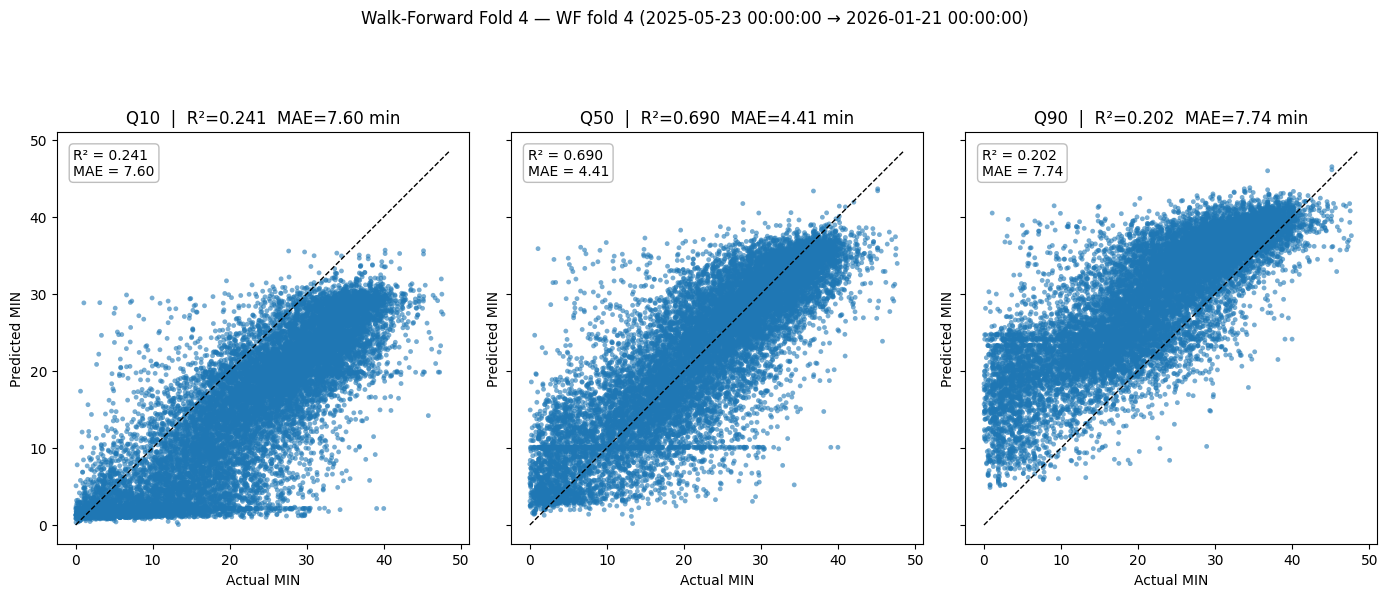

Per-quantile fit on last validation fold:
  Q10: R²=+0.241  MAE=7.598 min
  Q50: R²=+0.690  MAE=4.408 min
  Q90: R²=+0.202  MAE=7.739 min
Coverage per quantile (should match quantile value):
  Q10: 10.5%  (target 10%, delta +0.5%)
  Q50: 50.7%  (target 50%, delta +0.7%)
  Q90: 90.6%  (target 90%, delta +0.6%)

80% interval width (Q10→Q90):
  mean : 14.17 min
  median: 13.79 min
  std  : 2.90 min


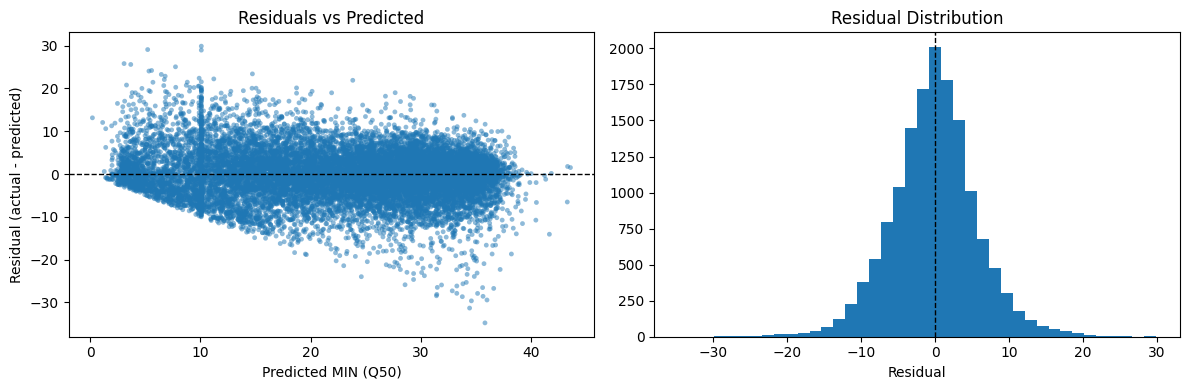


Residual summary:
  mean bias : -0.178 min  (close to 0 = unbiased)
  std       : 5.865 min


In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── pull from last walk-forward fold ─────────────────────────────────────────
last_fold   = wf_results[-1]
last_fold_n = last_fold["n"]

# re-identify the val slice from the last WF fold
fold        = N_FOLDS - 1
train_start = fold * STEP_SIZE
train_end   = train_start + TRAIN_WINDOW
val_end     = train_end + STEP_SIZE

X_val_last  = X.iloc[train_end:val_end]
y_val_last  = y.iloc[train_end:val_end]

# re-run predictions from the stored models (retrain if you didn't store them)
# if you stored models per fold, swap this block out
models_last, preds_last = fit_quantile_models(
    X.iloc[train_start:train_end],
    y.iloc[train_start:train_end],
    X_val_last,
    y_val_last,
)

y_true   = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter (with R^2 and MAE per quantile) ──────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
metrics = {}
for ax, (name, y_pred) in zip(axes, preds.items()):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    metrics[name] = {"R2": r2, "MAE": mae}

    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.2f} min")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")

    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.2f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward Fold {N_FOLDS} — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.3f} min")

# ── coverage per quantile ─────────────────────────────────────────────────────
print("Coverage per quantile (should match quantile value):")
for name, y_pred in preds.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})")

# ── interval width distribution ───────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean : {interval_width.mean():.2f} min")
print(f"  median: {np.median(interval_width):.2f} min")
print(f"  std  : {interval_width.std():.2f} min")

# ── residual plot (median only) ───────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted MIN (Q50)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

In [39]:
ppm_df = df[MIN_FEATURES + ["MIN", "GAME_DATE", "PLAYER_NAME"]].sort_values("GAME_DATE").reset_index(drop=True)

val_df = ppm_df.iloc[train_end:val_end].reset_index(drop=True)

player_col = "PLAYER_NAME" if "PLAYER_NAME" in val_df.columns else None
if player_col is None:
    raise ValueError("Add PLAYER_NAME to ppm_df columns (see comment above).")

pred50 = np.asarray(pred_mid).reshape(-1)
pred10 = np.asarray(pred_low).reshape(-1)
pred90 = np.asarray(pred_high).reshape(-1)

out = pd.DataFrame({
    "player": val_df[player_col].values,
    "actual_min": np.asarray(y_true).reshape(-1),
    "pred_min_q50": pred50,
    "interval_width": pred90 - pred10
})
out["error"] = out["actual_min"] - out["pred_min_q50"]
out["abs_error"] = out["error"].abs()

# optional: tie-break sort
if "GAME_DATE" in val_df.columns:
    out["game_date"] = val_df["GAME_DATE"].values

print(out.sort_values("interval_width", ascending=True).head(20).to_string(index=False))
print(f"\nMAE (Q50): {out['abs_error'].mean():.3f} | RMSE: {np.sqrt((out['error']**2).mean()):.3f}")

        player  actual_min  pred_min_q50  interval_width     error  abs_error  game_date
 James Johnson    2.111667      2.523014        3.541764 -0.411347   0.411347 2025-06-19
 Pacôme Dadiet    1.866667      2.821780        3.583452 -0.955114   0.955114 2025-05-31
 James Johnson    2.700000      2.528488        3.690406  0.171512   0.171512 2025-06-08
 James Johnson    2.111667      2.019359        3.722283  0.092307   0.092307 2025-06-19
 James Johnson    0.786667      1.998521        4.008944 -1.211855   1.211855 2025-05-31
Leonard Miller    7.683333      3.835769        4.063633  3.847565   3.847565 2025-05-24
 Johnny Furphy    0.786667      2.052233        4.074281 -1.265566   1.265566 2025-05-31
 Pacôme Dadiet    1.866667      2.111386        4.089865 -0.244720   0.244720 2025-05-31
 Johnny Furphy    1.850000      1.989262        4.408119 -0.139262   0.139262 2025-06-16
 James Johnson    2.700000      1.851828        4.441798  0.848172   0.848172 2025-06-08
 Johnny Furphy    0.7


── q_0.10 ──


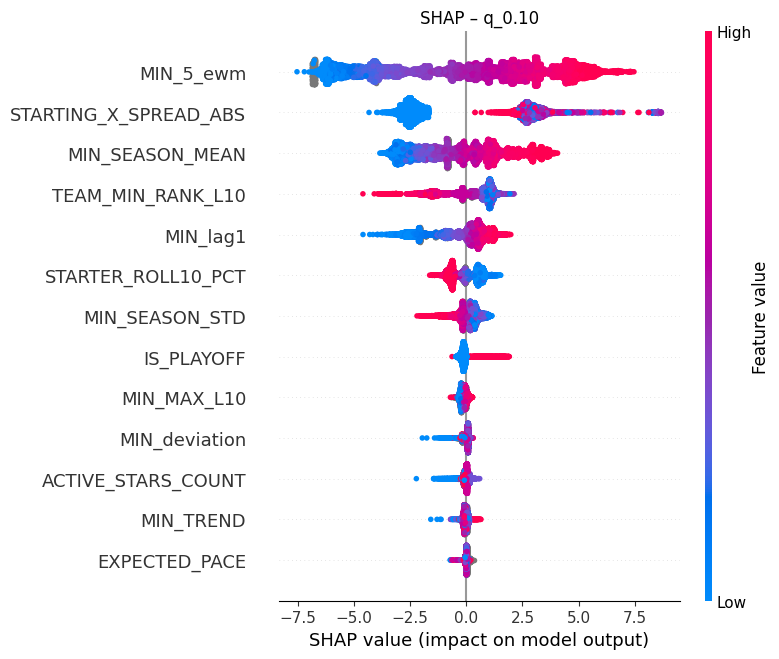


── q_0.50 ──


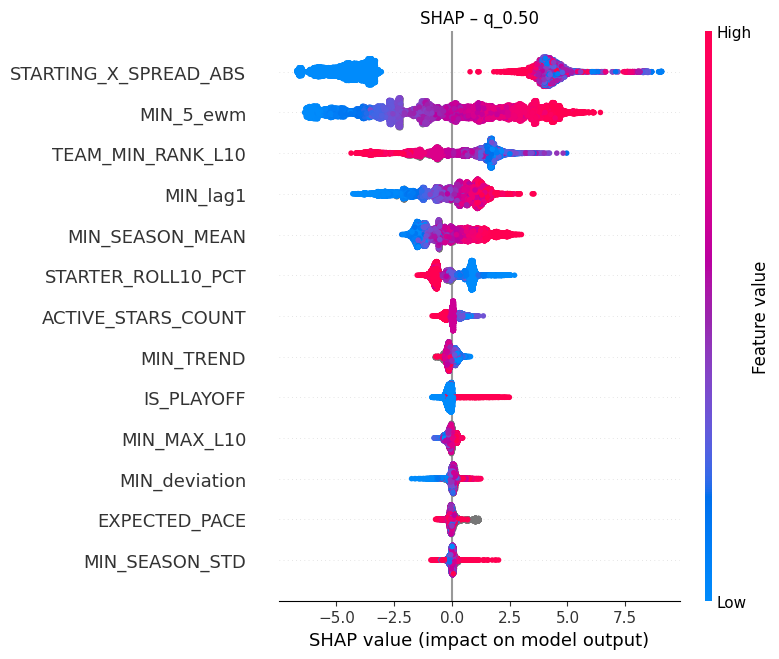


── q_0.90 ──


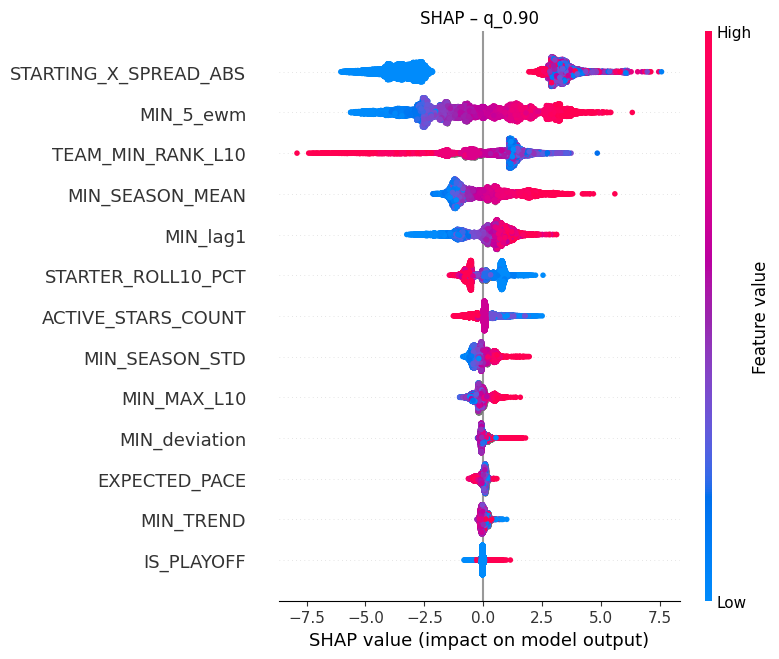

In [40]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

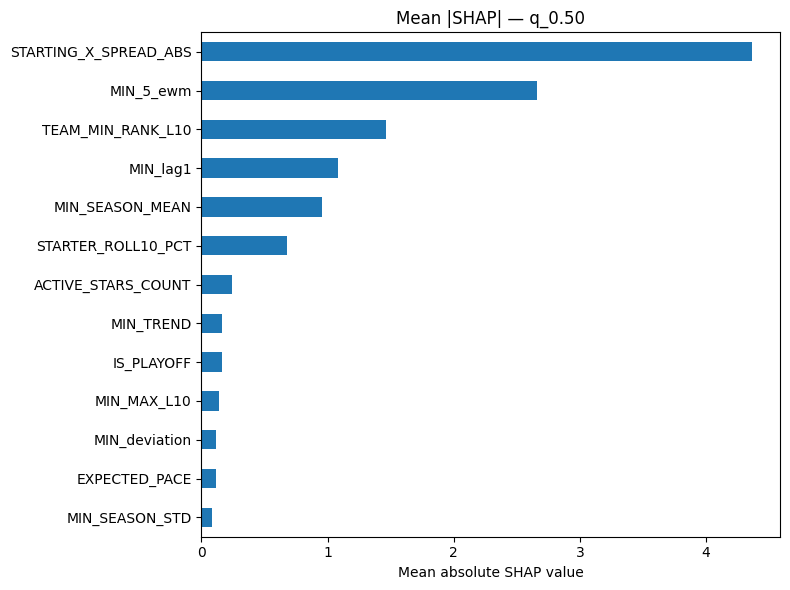

In [41]:
# fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# for ax, (q_key, model) in zip(axes, models_last.items()):
#     explainer   = shap.TreeExplainer(model)
#     shap_values = explainer(X_val_last)

#     mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
#     feat_imp      = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

#     feat_imp.plot(kind="barh", ax=ax)
#     ax.set_title(f"Mean |SHAP| — {q_key}")
#     ax.set_xlabel("Mean absolute SHAP value")

# plt.suptitle("Feature importance by quantile", y=1.02)
# plt.tight_layout()
# plt.show()

model = models_last["q_0.50"]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

In [42]:
import pandas as pd
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_tr,
    y_tr,
    n_repeats=30,
    random_state=42
)

pi_df = (
    pd.DataFrame({
        'feature':    X_tr.columns,
        'importance': result.importances_mean,
        'std':        result.importances_std,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

pi_df.index += 1  # rank starts at 1
pi_df['importance'] = pi_df['importance'].round(5)
pi_df['std']        = pi_df['std'].round(5)

print(pi_df.to_string())

                  feature  importance      std
1   STARTING_X_SPREAD_ABS     0.25965  0.00199
2               MIN_5_ewm     0.14735  0.00111
3       TEAM_MIN_RANK_L10     0.11976  0.00103
4                MIN_lag1     0.03349  0.00053
5      STARTER_ROLL10_PCT     0.02833  0.00035
6         MIN_SEASON_MEAN     0.02407  0.00040
7              IS_PLAYOFF     0.00797  0.00024
8           MIN_deviation     0.00414  0.00014
9      ACTIVE_STARS_COUNT     0.00387  0.00013
10          EXPECTED_PACE     0.00338  0.00009
11              MIN_TREND     0.00327  0.00009
12         MIN_SEASON_STD     0.00233  0.00006
13            MIN_MAX_L10     0.00093  0.00012


In [43]:
from sklearn.metrics import mean_squared_error

def rmse_median_ablation(feature_cols):
    X_tr = X.iloc[train_start:train_end][feature_cols]
    X_va = X.iloc[train_end:val_end][feature_cols]
    y_tr_ab = y.iloc[train_start:train_end]
    y_va_ab = y.iloc[train_end:val_end]
    m = XGBRegressor(**XGB_PARAMS, quantile_alpha=0.50)
    m.fit(X_tr, y_tr_ab, eval_set=[(X_va, y_va_ab)], verbose=False)
    pred = m.predict(X_va)
    return float(np.sqrt(mean_squared_error(y_va_ab, pred)))

baseline_rmse = rmse_median_ablation(MIN_FEATURES)

rows = []
for feat in MIN_FEATURES:
    cols = [c for c in MIN_FEATURES if c != feat]
    ablated_rmse = rmse_median_ablation(cols)
    delta = ablated_rmse - baseline_rmse  # positive ⇒ removing it hurts ⇒ feature helped
    rows.append({"feature": feat, "ablated_rmse": ablated_rmse, "delta_rmse": delta})

ablation_df = pd.DataFrame(rows).sort_values("delta_rmse", ascending=False)
ablation_df

,feature,ablated_rmse,delta_rmse
0,STARTING_X_SPREAD_ABS,6.255519,0.388249
2,TEAM_MIN_RANK_L10,5.946592,0.079322
3,STARTER_ROLL10_PCT,5.906103,0.038833
10,ACTIVE_STARS_COUNT,5.881610,0.014340
11,EXPECTED_PACE,5.880005,0.012735
8,IS_PLAYOFF,5.879174,0.011903
1,MIN_5_ewm,5.879118,0.011848
7,MIN_MAX_L10,5.877138,0.009867
9,MIN_deviation,5.873952,0.006682
4,MIN_SEASON_MEAN,5.873280,0.006010


In [44]:
from scipy import stats

# Needs: `shap`, `model`, `X_tr`, `result`, `pi_df`, `ablation_df`, `PPM_FEATURES`.

_shap_expl = shap.TreeExplainer(model)
_shap_vals = _shap_expl(X_tr)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    'feature': MIN_FEATURES,
    'mean_abs_shap': _mean_abs_shap,
}).assign(
    shap_rank=lambda d: d['mean_abs_shap'].rank(method='min', ascending=False).astype(int)
)

perm_table = (
    pi_df.sort_values('importance', ascending=False)
    .reset_index(drop=True)
    .rename(columns={'importance': 'perm_importance', 'std': 'perm_importance_std'})
)
perm_table['perm_rank'] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[['feature', 'perm_rank', 'perm_importance', 'perm_importance_std']]

perm_pv = pd.DataFrame({
    'feature': X_tr.columns,
    'perm_pvalue': stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy='omit').pvalue
})

abla = ablation_df[['feature', 'delta_rmse']].rename(columns={'delta_rmse': 'ablation_delta'})

feature_audit = (
    pd.DataFrame({'feature': MIN_FEATURES})
    .merge(shap_table, on='feature', how='left')
    .merge(perm_table, on='feature', how='left')
    .merge(perm_pv, on='feature', how='left')
    .merge(abla, on='feature', how='left')
)

# Magnitude consensus: divide by column max (no rank forcing ~0 at the bottom).
_ms = feature_audit['mean_abs_shap'].astype(float)
_mp = feature_audit['perm_importance'].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit['shap_norm'] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit['perm_norm'] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit['consensus'] = (feature_audit['shap_norm'] + feature_audit['perm_norm']) / 2

feature_audit.sort_values('consensus', ascending=False)

,feature,mean_abs_shap,shap_rank,perm_rank,perm_importance,perm_importance_std,perm_pvalue,ablation_delta,shap_norm,perm_norm,consensus
0,STARTING_X_SPREAD_ABS,4.374090,1,1,0.25965,0.00199,6.925765e-63,0.388249,1.000000,1.000000,1.000000
1,MIN_5_ewm,2.852946,2,2,0.14735,0.00111,4.222848e-63,0.011848,0.652238,0.567495,0.609866
2,TEAM_MIN_RANK_L10,1.538109,3,3,0.11976,0.00103,1.745124e-61,0.079322,0.351641,0.461236,0.406439
5,MIN_lag1,1.191932,4,4,0.03349,0.00053,1.051609e-53,0.005046,0.272498,0.128981,0.200740
4,MIN_SEASON_MEAN,1.013124,5,6,0.02407,0.00040,2.555740e-53,0.006010,0.231619,0.092702,0.162161
3,STARTER_ROLL10_PCT,0.715978,6,5,0.02833,0.00035,7.528416e-57,0.038833,0.163686,0.109108,0.136397
8,IS_PLAYOFF,0.244024,8,7,0.00797,0.00024,1.051620e-45,0.011903,0.055788,0.030695,0.043242
10,ACTIVE_STARS_COUNT,0.262097,7,9,0.00387,0.00013,6.050857e-44,0.014340,0.059920,0.014905,0.037413
9,MIN_deviation,0.169409,10,8,0.00414,0.00014,2.573242e-44,0.006682,0.038730,0.015945,0.027337
12,MIN_TREND,0.170062,9,11,0.00327,0.00009,1.870258e-47,0.005867,0.038879,0.012594,0.025737


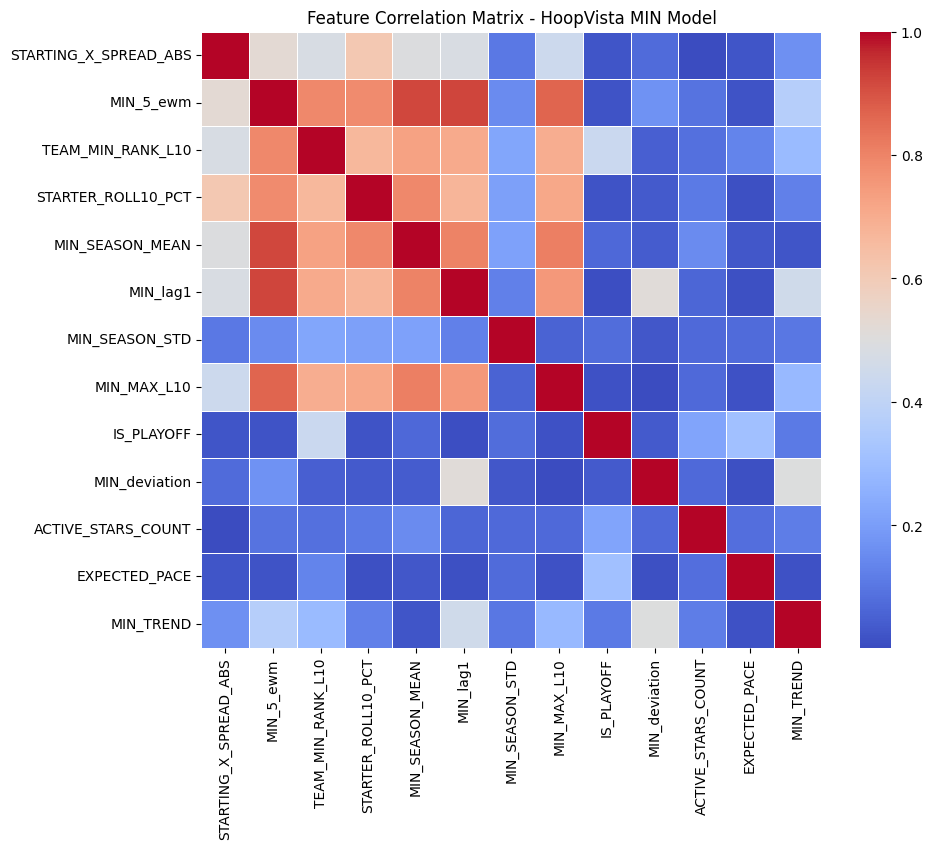

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [45]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, MIN_FEATURES)
correlated_features

In [46]:
import joblib
from pathlib import Path

# save_dir = Path("models")
# save_dir.mkdir(exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_last,       # from final WF fold
    "feature_names":   MIN_FEATURES,
    "fold_metrics":    wf_results,        # full validation history
    "train_end":       last_fold["train_end"],
    "val_end":         last_fold["val_end"],
}

save_path = f"min_quantile_xgb_{last_fold['val_end'].date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle         = joblib.load(save_path)
models_loaded  = bundle["quantile_models"]
feature_names  = bundle["feature_names"]

# sanity check — should match your walk-forward MAE
test_preds = models_loaded["q_0.50"].predict(X_val_last)
print(f"Loaded model MAE: {mean_absolute_error(y_val_last, test_preds):.3f}")
print(f"Trained on data up to: {bundle['train_end']}")
print(f"Validated on data up to: {bundle['val_end']}")

# ── inference (new data) ──────────────────────────────────────────────────────
def predict_minutes(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a dataframe with the same columns as MIN_FEATURES.
    Returns Q10/Q50/Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to min_quantile_xgb_2026-01-21.joblib
Loaded model MAE: 4.408
Trained on data up to: 2025-05-23 00:00:00
Validated on data up to: 2026-01-21 00:00:00
